# Electric drives, part 2: field-oriented control

Part 1 left us with a sobering result: drive an interior PMSM open-loop and it is
*unstable* above a modest speed, and even where it is stable it has no load
regulation — speed sagged from 669 to 185 rpm under a 1.2 N·m load. This notebook
fixes all of that with **field-oriented control (FOC)**: transform the three
phase currents into the rotor frame, regulate the d- and q-axis currents with
decoupled PI loops, and wrap a speed loop on top. The same differentiable
Jaxonomy machine from Part 1 is the plant.

**By the end you will be able to:**
1. Build the Clarke and Park transforms and the dq **decoupling** feedforward.
2. Design current-loop gains by internal-model control (pole–zero cancellation)
   and verify the closed-loop bandwidth against the first-order prediction.
3. Close a cascaded speed→current loop that tracks a setpoint with zero
   steady-state error and full load rejection.
4. Find the **maximum-torque-per-amp (MTPA)** operating point that exploits
   saliency to cut copper loss.

*Reading time ~30 min · runtime ~2 min on CPU.*

> **Position in the series.** Builds directly on Part 1's `PMSM` block (re-inlined
> below so this notebook stands alone). Adds the controller; the machine model is
> unchanged. Part 3 will heat the windings and derate the torque.

> **Out of scope, on purpose.** Sensorless rotor-angle estimation (we assume the
> angle is measured — observer design is its own topic), discrete-time controller
> implementation and PWM (Part 6 handles fixed-point/embedded), and field
> weakening above base speed (sketched in §7, left as the headline exercise).

In [1]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp
import jaxonomy
from jaxonomy import DiagramBuilder, LeafSystem, simulate, SimulatorOptions
from jaxonomy.library import Constant
from jaxonomy.framework import DependencyTicket
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)
np.random.seed(0)

PARAMS = dict(R=0.45, Ld=3.2e-3, Lq=5.8e-3, lam=0.0533, p=4.0, J=1.2e-3, B=8.0e-5)
V_DC = 48.0; V_LIM = V_DC/np.sqrt(3.0)
Kt = 1.5*PARAMS["p"]*PARAMS["lam"]          # magnet torque constant (i_d=0)
print(f"jaxonomy {jaxonomy.__version__} | Kt={Kt:.4f} N·m/A | V_lim={V_LIM:.2f} V")

jaxonomy 2.2.0 | Kt=0.3198 N·m/A | V_lim=27.71 V


## 1 · The machine (recap) and the rotor-frame idea

The plant is Part 1's interior PMSM, repeated here so the notebook is
self-contained. The state is $x=[i_d,i_q,\omega_m,\theta_m]$ and the input is
$v_{dq}$.

In [2]:
def pmsm_ode_rhs(x, v_dq, t, *, R, Ld, Lq, lam, p, J, B, T_load=0.0):
    i_d, i_q, w_m, _th = x
    v_d, v_q = v_dq[0], v_dq[1]
    w_e = p*w_m
    di_d = (v_d - R*i_d + w_e*Lq*i_q)/Ld
    di_q = (v_q - R*i_q - w_e*(Ld*i_d + lam))/Lq
    Te = 1.5*p*(lam*i_q + (Ld-Lq)*i_d*i_q)
    return jnp.array([di_d, di_q, (Te - B*w_m - T_load)/J, w_m])

class PMSM(LeafSystem):
    def __init__(self, params=PARAMS, x0=None, T_load=0.0, name="pmsm"):
        super().__init__(name=name)
        for k, v in params.items():
            self.declare_dynamic_parameter(k, float(v))
        self.declare_dynamic_parameter("T_load", float(T_load))
        if x0 is None:
            x0 = jnp.zeros(4)
        self.declare_input_port(name="v_dq")
        self.declare_continuous_state(default_value=jnp.asarray(x0, float), ode=self.ode)
        self.declare_continuous_state_output(name="x")
    def ode(self, time, state, *inputs, **p):
        (v_dq,) = inputs
        return pmsm_ode_rhs(state.continuous_state, v_dq, time, R=p["R"], Ld=p["Ld"],
            Lq=p["Lq"], lam=p["lam"], p=p["p"], J=p["J"], B=p["B"], T_load=p["T_load"])

### Clarke and Park: from three phases to two rotating axes

Real hardware measures three phase currents $i_a, i_b, i_c$. Two transforms turn
them into the dq pair the machine model speaks. The **Clarke** transform projects
the (balanced) three-phase set onto a stationary two-axis $(\alpha,\beta)$ frame;
the **Park** transform rotates that into the dq frame aligned with the rotor at
electrical angle $\theta_e$:

$$
\begin{bmatrix}i_\alpha\\i_\beta\end{bmatrix}=\frac{2}{3}
\begin{bmatrix}1&-\tfrac12&-\tfrac12\\[2pt]0&\tfrac{\sqrt3}{2}&-\tfrac{\sqrt3}{2}\end{bmatrix}
\begin{bmatrix}i_a\\i_b\\i_c\end{bmatrix},\qquad
\begin{bmatrix}i_d\\i_q\end{bmatrix}=
\begin{bmatrix}\cos\theta_e&\sin\theta_e\\-\sin\theta_e&\cos\theta_e\end{bmatrix}
\begin{bmatrix}i_\alpha\\i_\beta\end{bmatrix}.
$$

The inverse pair turns the controller's $v_{dq}$ command back into three phase
voltages for the inverter. We use the **amplitude-invariant** ($2/3$) convention,
consistent with Part 1's $\tfrac32$ power factor.

In [3]:
def clarke(abc):
    a, b, c = abc[0], abc[1], abc[2]
    return jnp.array([(2*a - b - c)/3.0, (b - c)/jnp.sqrt(3.0)])
def park(ab, th):
    al, be = ab; ct, st = jnp.cos(th), jnp.sin(th)
    return jnp.array([ct*al + st*be, -st*al + ct*be])
def inv_park(dq, th):
    d, q = dq; ct, st = jnp.cos(th), jnp.sin(th)
    return jnp.array([ct*d - st*q, st*d + ct*q])
def inv_clarke(ab):
    al, be = ab
    return jnp.array([al, -0.5*al + jnp.sqrt(3)/2*be, -0.5*al - jnp.sqrt(3)/2*be])

# round-trip identity (zero-sequence-free), to machine precision
_abc = jnp.array([2.0, -1.3, -0.7]); _abc = _abc - jnp.mean(_abc)
_rt = inv_clarke(inv_park(park(clarke(_abc), 0.9), 0.9))
print(f"Clarke/Park round-trip error: {float(jnp.max(jnp.abs(_rt-_abc))):.2e}")

Clarke/Park round-trip error: 0.00e+00


## 2 · Decoupling: making each axis a clean first-order plant

The dq currents are cross-coupled through the speed-voltage terms in Part 1's
Eq. (2). FOC cancels them with a **feedforward**:

$$
v_d = \underbrace{K^d_p e_d + K^d_i\!\int\! e_d}_{\text{PI}} \;-\; \omega_e L_q i_q,
\qquad
v_q = \underbrace{K^q_p e_q + K^q_i\!\int\! e_q}_{\text{PI}} \;+\; \omega_e (L_d i_d + \lambda_m),
$$

with $e_d = i_d^\star - i_d$, $e_q = i_q^\star - i_q$. Substituting into the plant,
the cross terms vanish and each axis collapses to a first-order RL system driven
by its PI output, e.g. $L_q \dot i_q = \text{PI}_q - R\,i_q$. With **internal-model
control** the PI zero cancels the plant pole — choose

$$
K^q_p = L_q\,\omega_{bw},\quad K^q_i = R\,\omega_{bw}\;\;\Rightarrow\;\;
\frac{i_q}{i_q^\star}=\frac{\omega_{bw}}{s+\omega_{bw}},
$$

a clean first-order loop of bandwidth $\omega_{bw}$ (and identically for d with
$L_d$). The speed loop closes around the torque $T_e\approx K_t i_q$ with a
critically-damped PI.

In [4]:
def foc_gains(bw_i_hz, bw_w_hz, params=PARAMS):
    wi = 2*np.pi*bw_i_hz
    g = dict(Kp_d=params["Ld"]*wi, Ki_d=params["R"]*wi,
             Kp_q=params["Lq"]*wi, Ki_q=params["R"]*wi)
    ww = 2*np.pi*bw_w_hz; zeta = 1.0
    g["Kp_w"] = 2*zeta*ww*params["J"]/Kt
    g["Ki_w"] = ww*ww*params["J"]/Kt
    return g

class FOCController(LeafSystem):
    """Cascaded speed->current FOC with dq decoupling and voltage limiting.
    inputs: 0 = plant state x[4], 1 = reference (speed [rad/s] or i_q [A]).
    state: [xi_d, xi_q, xi_w] integral terms.  output: v_dq[2].
    mode='speed' runs the cascade; mode='current' commands i_q directly (torque)."""
    def __init__(self, gains, params=PARAMS, mode="speed", id_ref=0.0, iq_max=60.0,
                 decouple=True, v_lim=V_LIM, name="foc"):
        super().__init__(name=name)
        self.p, self.g = dict(params), dict(gains)
        self.mode, self.id_ref = mode, float(id_ref)
        self.iq_max, self.decouple, self.v_lim = float(iq_max), bool(decouple), float(v_lim)
        self.declare_input_port(name="x")
        self.declare_input_port(name="ref")
        self.declare_continuous_state(default_value=jnp.zeros(3), ode=self._ode, requires_inputs=True)
        self.declare_output_port(self._out, name="v_dq", requires_inputs=True,
                                 prerequisites_of_calc=[DependencyTicket.xc])
    def _cmds(self, xi, x, ref):
        i_d, i_q, w_m, _ = x
        if self.mode == "current":
            iq_ref, e_w = ref, 0.0
        else:
            e_w = ref - w_m
            iq_ref = jnp.clip(self.g["Kp_w"]*e_w + self.g["Ki_w"]*xi[2], -self.iq_max, self.iq_max)
        return (self.id_ref - i_d), (iq_ref - i_q), e_w, i_d, i_q, w_m
    def _ode(self, time, state, *inputs):
        x, ref = inputs[0], jnp.atleast_1d(inputs[1])[0]
        e_d, e_q, e_w, *_ = self._cmds(state.continuous_state, x, ref)
        return jnp.array([e_d, e_q, e_w])
    def _out(self, time, state, *inputs):
        xi = state.continuous_state
        x, ref = inputs[0], jnp.atleast_1d(inputs[1])[0]
        e_d, e_q, e_w, i_d, i_q, w_m = self._cmds(xi, x, ref)
        w_e = self.p["p"]*w_m
        vd_ff = jnp.where(self.decouple, -w_e*self.p["Lq"]*i_q, 0.0)
        vq_ff = jnp.where(self.decouple, w_e*(self.p["Ld"]*i_d + self.p["lam"]), 0.0)
        vd = self.g["Kp_d"]*e_d + self.g["Ki_d"]*xi[0] + vd_ff
        vq = self.g["Kp_q"]*e_q + self.g["Ki_q"]*xi[1] + vq_ff
        mag = jnp.sqrt(vd*vd + vq*vq) + 1e-12
        scale = jnp.minimum(1.0, self.v_lim/mag)
        return jnp.array([vd*scale, vq*scale])

def run_foc(ref, t_end, *, mode="speed", x0=None, J=None, gains=None, id_ref=0.0,
            decouple=True, T_load=0.0, n=6000):
    params = dict(PARAMS)
    if J is not None: params["J"] = J
    if gains is None: gains = foc_gains(200, 8, params)
    b = DiagramBuilder()
    plant = b.add(PMSM(params=params, x0=x0, T_load=T_load))
    ctrl = b.add(FOCController(gains, params=params, mode=mode, id_ref=id_ref, decouple=decouple))
    src = b.add(Constant(jnp.asarray(float(ref)), name="ref"))
    b.connect(plant.output_ports[0], ctrl.input_ports[0])
    b.connect(src.output_ports[0], ctrl.input_ports[1])
    b.connect(ctrl.output_ports[0], plant.input_ports[0])
    diag = b.build(); ctx = diag.create_context()
    res = simulate(diag, ctx, (0.0, t_end), options=SimulatorOptions(max_major_step_length=t_end/n),
                   recorded_signals={"x": plant.output_ports[0], "v": ctrl.output_ports[0]})
    return np.asarray(res.time), np.asarray(res.outputs["x"]), np.asarray(res.outputs["v"])
print("FOC controller ready.")

FOC controller ready.


## 3 · Validation I — current-loop bandwidth

In **current (torque) mode** we command $i_q^\star$ directly. Freezing the rotor
speed (large inertia) isolates the inner loop, and a *small* step keeps us off the
voltage limit so the linear design applies. The response should be the
first-order $1-e^{-t/\tau}$ with $\tau = 1/\omega_{bw}$.

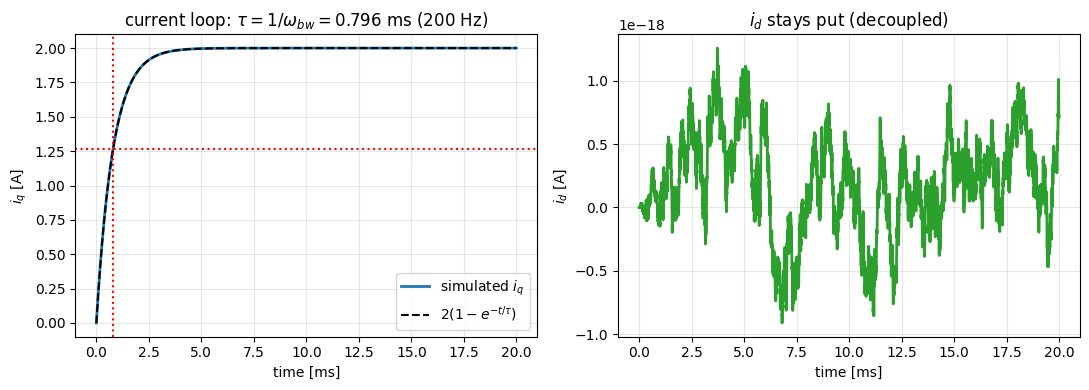

i_q steady = 2.000 A (target 2.0) | rise time 0.797 ms vs tau 0.796 ms


In [5]:
bw = 200.0                                   # current-loop bandwidth [Hz]
g = foc_gains(bw, 8)
t, X, V = run_foc(2.0, 0.02, mode="current", J=1e6, gains=g,
                  x0=jnp.array([0.,0.,30.,0.]), n=8000)
iq = X[:,1]; tau = 1/(2*np.pi*bw); ana = 2.0*(1-np.exp(-t/tau))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t*1e3, iq, lw=2, label="simulated $i_q$")
ax[0].plot(t*1e3, ana, "k--", label=r"$2(1-e^{-t/\tau})$")
ax[0].axvline(tau*1e3, color="r", ls=":"); ax[0].axhline(0.632*2, color="r", ls=":")
ax[0].set_title(f"current loop: $\\tau=1/\\omega_{{bw}}={tau*1e3:.3f}$ ms ({bw:.0f} Hz)")
ax[0].set_xlabel("time [ms]"); ax[0].set_ylabel("$i_q$ [A]"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot(t*1e3, X[:,0], lw=2, color="C2"); ax[1].set_title("$i_d$ stays put (decoupled)")
ax[1].set_xlabel("time [ms]"); ax[1].set_ylabel("$i_d$ [A]"); ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

t_rise = t[np.argmax(iq >= 0.632*iq[-1])]
print(f"i_q steady = {iq[-1]:.3f} A (target 2.0) | rise time {t_rise*1e3:.3f} ms vs tau {tau*1e3:.3f} ms")
assert abs(iq[-1]-2.0) < 0.1 and abs(t_rise-tau)/tau < 0.25

**Figure 1.** The small-signal current step lands on the first-order curve
with $\tau=1/\omega_{bw}$ to within the sample spacing, and $i_d$ barely moves —
the decoupling is doing its job. (For *large* steps the response is slew-limited
by the DC bus; that saturation is the subject of §7.)

## 4 · Validation II — decoupling earns its keep

Turn the feedforward off and the same $i_q$ step kicks $i_d$ through the
$\omega_e L_q i_q$ cross term. With decoupling on, $i_d$ stays near zero.

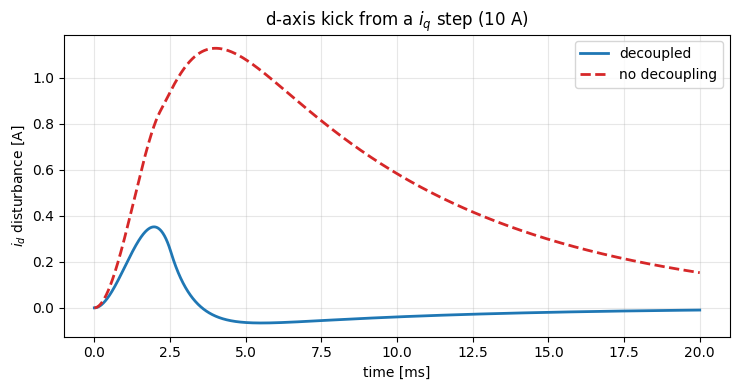

max |i_d|: decoupled 0.352 A  vs  off 1.128 A


In [6]:
_, Xc, _ = run_foc(10.0, 0.02, mode="current", J=1e6, gains=g, x0=jnp.array([0.,0.,30.,0.]), decouple=True, n=8000)
_, Xn, _ = run_foc(10.0, 0.02, mode="current", J=1e6, gains=g, x0=jnp.array([0.,0.,30.,0.]), decouple=False, n=8000)
tt = np.linspace(0, 0.02, Xc.shape[0])
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tt*1e3, Xc[:,0], lw=2, label="decoupled")
ax.plot(tt*1e3, Xn[:,0], lw=2, ls="--", color="C3", label="no decoupling")
ax.set_xlabel("time [ms]"); ax.set_ylabel("$i_d$ disturbance [A]")
ax.set_title("d-axis kick from a $i_q$ step (10 A)"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); plt.show()
print(f"max |i_d|: decoupled {np.max(np.abs(Xc[:,0])):.3f} A  vs  off {np.max(np.abs(Xn[:,0])):.3f} A")
assert np.max(np.abs(Xc[:,0])) < np.max(np.abs(Xn[:,0]))

**Figure 2.** Without decoupling, a q-axis step bleeds into the d-axis (it
would corrupt torque accuracy and, at higher speed, destabilise the loop). The
feedforward cuts the peak disturbance roughly threefold.

## 5 · The payoff — speed tracking with load regulation

This is what Part 1 could not do. We command 800 rpm and apply two different
loads. The cascade tracks the setpoint with **zero steady-state error in both
cases** — the integral action rejects the load entirely. Recall open-loop in
Part 1 sagged from 669 to 185 rpm under load.

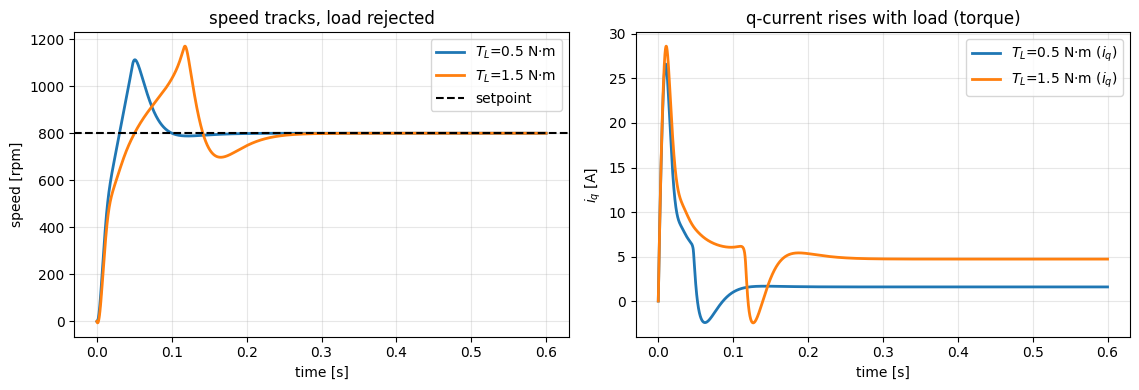

T_L=0.5: steady 800 rpm (target 800)
T_L=1.5: steady 800 rpm (target 800)


In [7]:
w_ref = 800*2*np.pi/60
res = {}
for TL, c in [(0.5, "C0"), (1.5, "C1")]:
    t, X, V = run_foc(w_ref, 0.6, mode="speed", T_load=TL, n=6000)
    res[TL] = (t, X, V)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
for TL, c in [(0.5, "C0"), (1.5, "C1")]:
    t, X, V = res[TL]
    ax[0].plot(t, X[:,2]*60/(2*np.pi), lw=2, color=c, label=f"$T_L$={TL} N·m")
    ax[1].plot(t, X[:,1], lw=2, color=c, label=f"$T_L$={TL} N·m ($i_q$)")
ax[0].axhline(800, color="k", ls="--", label="setpoint"); ax[0].set_title("speed tracks, load rejected")
ax[0].set_ylabel("speed [rpm]")
ax[1].set_title("q-current rises with load (torque)"); ax[1].set_ylabel("$i_q$ [A]")
for a in ax: a.set_xlabel("time [s]"); a.grid(alpha=.3); a.legend()
fig.tight_layout(); plt.show()
for TL in (0.5, 1.5):
    rpm = res[TL][1][-1,2]*60/(2*np.pi)
    print(f"T_L={TL}: steady {rpm:.0f} rpm (target 800)")
    assert abs(rpm-800)/800 < 0.02

**Figure 3.** Both loads converge to exactly 800 rpm; the heavier load
simply draws more $i_q$ (more torque) at the same speed. Zero steady-state error
under a 3× load change is the integral action of the speed loop — the cure for
Part 1's open-loop sag.

## 6 · MTPA — using saliency to cut losses

For a *target torque* there is a one-parameter family of $(i_d, i_q)$ that
produces it (Part 1's Eq. 3). The **maximum-torque-per-amp** point minimises
$i_d^2+i_q^2$ — i.e. copper loss. Because the interior machine has $L_q>L_d$, the
optimum sits at $i_d<0$, harvesting reluctance torque. We solve it numerically
with the same model.

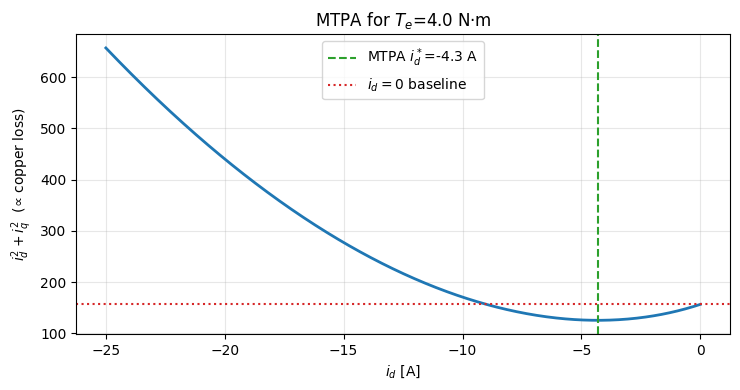

i_d*=-4.30 A -> 20% less copper loss than i_d=0


In [8]:
Te_target = 4.0
def iq_for(i_d):
    return Te_target/(1.5*PARAMS["p"]*(PARAMS["lam"] + (PARAMS["Ld"]-PARAMS["Lq"])*i_d))
ids = np.linspace(-25, 0, 600); loss = ids**2 + np.array([iq_for(x) for x in ids])**2
i_mtpa = ids[np.argmin(loss)]; loss0 = 0**2 + iq_for(0.0)**2
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(ids, loss, lw=2); ax.axvline(i_mtpa, color="C2", ls="--", label=f"MTPA $i_d^*$={i_mtpa:.1f} A")
ax.axhline(loss0, color="C3", ls=":", label="$i_d=0$ baseline")
ax.set_xlabel("$i_d$ [A]"); ax.set_ylabel("$i_d^2+i_q^2$  (∝ copper loss)")
ax.set_title(f"MTPA for $T_e$={Te_target} N·m"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); plt.show()
print(f"i_d*={i_mtpa:.2f} A -> {100*(1-loss.min()/loss0):.0f}% less copper loss than i_d=0")
assert i_mtpa < -0.5 and loss.min() < loss0

**Figure 4.** Feeding $i_d^*\approx-4.3$ A instead of zero produces the same
4 N·m with ~20% less copper loss. Wiring `id_ref=i_mtpa` into the controller
(rather than 0) is a one-line change — left as an exercise.

## 7 · Limits — the voltage budget and base speed

FOC is not magic: the inverter can only synthesise $|v_{dq}|\le V_\mathrm{dc}/\sqrt3$.
As speed rises, the back-EMF $\omega_e\lambda_m$ consumes the budget, and the
**d-axis decoupling voltage** $\omega_e L_q i_q$ consumes more. Past **base speed**
the only way to go faster is *field weakening* — commanding $i_d<0$ to suppress
flux. The plot maps the steady voltage magnitude against commanded speed at fixed
load; where it hits $V_\mathrm{lim}$ is base speed.

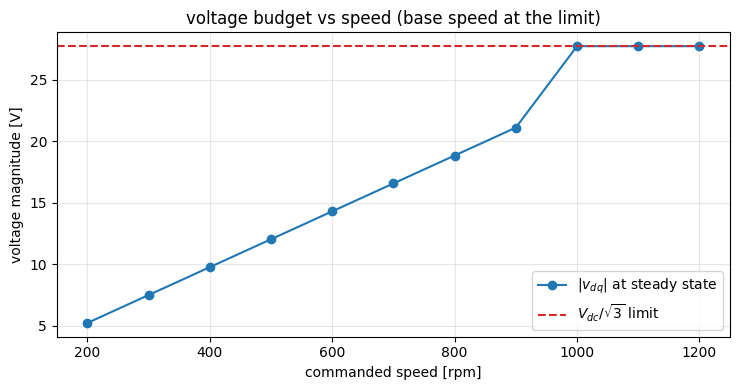

voltage at 1200 rpm: 27.7 V of 27.7 V available


In [9]:
speeds = np.arange(200, 1300, 100)
vmag = []
for rpm in speeds:
    t, X, V = run_foc(rpm*2*np.pi/60, 0.6, mode="speed", T_load=0.5, n=2500)
    vmag.append(np.sqrt(V[-1,0]**2 + V[-1,1]**2))
vmag = np.array(vmag)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(speeds, vmag, "o-", label="$|v_{dq}|$ at steady state")
ax.axhline(V_LIM, color="C3", ls="--", label="$V_{dc}/\\sqrt{3}$ limit")
ax.set_xlabel("commanded speed [rpm]"); ax.set_ylabel("voltage magnitude [V]")
ax.set_title("voltage budget vs speed (base speed at the limit)"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); plt.show()
print(f"voltage at 1200 rpm: {vmag[-1]:.1f} V of {V_LIM:.1f} V available")

**Figure 5.** Voltage demand climbs with speed; once it reaches the bus
limit, the loop saturates and tracking degrades — the boundary the field-weakening
exercise pushes past.

## Exercises

- **(Easy)** Set `id_ref` to the MTPA value from §6 and confirm the same speed/
  torque at lower current.
- **(Medium)** Halve the current-loop bandwidth and re-measure $\tau$; confirm it
  doubles. What goes wrong if you push $\omega_{bw}$ toward the (eventual) PWM rate?
- **(Hard)** Implement field weakening: make `id_ref` a function of speed that
  keeps $|v_{dq}|$ at the limit above base speed, and show the machine exceeds the
  base speed of §7.
- **(Open)** Add anti-windup to the speed PI (the integrator currently keeps
  integrating when $i_q^\star$ saturates). Demonstrate the improvement on a large
  setpoint step.

## Next steps

**Part 3 — Thermal and derating** couples the $I^2R$ losses this controller
produces into a thermal network, lets the winding heat up, and derates $R$ and
$\lambda_m$ with temperature — then runs the fast electrical loop and the slow
thermal loop together as a multi-rate system.

## References

1. P. Krause et al., *Analysis of Electric Machinery and Drive Systems*, 3rd ed.,
   Wiley-IEEE, 2013 — dq decoupling and current control.
2. L. Harnefors & H.-P. Nee, "Model-based current control of AC machines using
   the internal model control method," *IEEE Trans. Ind. Appl.*, 1998 — the IMC
   gain rule used in §2.
3. S. Morimoto et al., "Expansion of operating limits for PM motor by current
   vector control considering inverter capacity," *IEEE Trans. Ind. Appl.*, 1990
   — MTPA and field weakening.
4. N. Mohan, *Advanced Electric Drives*, Wiley, 2014 — cascaded speed/current FOC.